In [55]:
# === CPU SETUP ===
import tensorflow as tf
import os

# Detect CPU core count and configure threading
cpu_count = os.cpu_count()
print(f"CPU cores detected: {cpu_count}")

# Set TensorFlow to use all available CPU threads for parallel operations
tf.config.threading.set_intra_op_parallelism_threads(cpu_count)
tf.config.threading.set_inter_op_parallelism_threads(cpu_count)

# Optional: Set environment variables for MKL/oneDNN CPU acceleration
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '1'
os.environ['KMP_BLOCKTIME'] = '0'
os.environ['KMP_SETTINGS'] = '1'
os.environ['OMP_NUM_THREADS'] = str(cpu_count)

print("CPU threading and oneDNN optimizations configured.")

CPU cores detected: 8
CPU threading and oneDNN optimizations configured.


In [56]:
import os
import urllib.request
import zipfile
import shutil

# === CONFIGURATION ===
# Data is stored in a 'roadsigns_data' folder inside this repo/project directory.
DATA_DIR = os.path.join(os.path.abspath('.'), 'roadsigns_data')
# Or override manually, e.g.:
# DATA_DIR = r'C:\Users\elijk\Documents\DS-450\signs\roadsigns_data'

os.makedirs(DATA_DIR, exist_ok=True)

training_dir = os.path.join(DATA_DIR, "training")
holdout_dir = os.path.join(DATA_DIR, "holdout")
mini_holdout_dir = os.path.join(DATA_DIR, "mini_holdout")
mini_holdout_answers = os.path.join(DATA_DIR, "mini_holdout_answers.csv")

In [57]:
# Import libraries
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import accuracy_score, classification_report
import cv2
import numpy as np

In [58]:
# We're using keras' ImageDataGenerator class to load our image data.
# See (https://keras.io/api/preprocessing/image/#imagedatagenerator-class) for details
#
# A couple of things to note:
# 1. We're specifying a number for the seed, so we'll always get the same shuffle and split of our images.
# 2. Class names are inferred automatically from the image subdirectory names.
# 3. We're splitting the training data into 80% training, 20% validation.
# 4. workers uses all CPU cores for parallel data loading.


def hybrid_blur_preprocessing(image):
    """
    Dynamically applies motion blur, Gaussian blur, both, or neither 
    to simulate complex real-world driving conditions.
    """
    # 1. MOTION BLUR (20% chance) - Simulates speed streaks/vibrations
    if np.random.rand() < 0.2:
        intensity = np.random.choice([3, 5, 7])
        kernel = np.zeros((intensity, intensity))
        kernel[int((intensity - 1) / 2), :] = np.ones(intensity)
        
        # Random angle for the streak
        angle = np.random.uniform(-20, 20)
        rotation_matrix = cv2.getRotationMatrix2D((intensity / 2, intensity / 2), angle, 1)
        kernel = cv2.warpAffine(kernel, rotation_matrix, (intensity, intensity))
        kernel = kernel / np.sum(kernel)
        
        image = cv2.filter2D(image, -1, kernel)
        
    # 2. GAUSSIAN BLUR (20% chance) - Simulates a dirty lens or defocus
    if np.random.rand() < 0.2:
        # Keeping kernel sizes small so the image doesn't become completely unreadable
        kernel_size = np.random.choice([3, 5])
        image = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
        
    return image


training_dir = os.path.join(DATA_DIR, 'training')
image_size = (100, 100)

# Split up the training data images into training and validations sets
# We'll use and ImageDataGenerator to do the splits
# ImageDataGenerator can also be used to do preprocessing and agumentation on the files as can be seen with rescale

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=.2,

    # === HYBRID BLUR IMPLEMENTATION ===
    preprocessing_function=hybrid_blur_preprocessing,  # <--- Plugs in here

    # === GEOMETRIC AUGMENTATIONS ===
    rotation_range=15,            
    width_shift_range=0.1,        
    height_shift_range=0.1,       
    shear_range=0.1,              
    zoom_range=0.5,               

    # === COLOR & BRIGHTNESS ===
    brightness_range=[0.1, 1.9],   
    channel_shift_range=0.1,      

    # === CANVAS FILL STRATEGY ===
    fill_mode='nearest',          
)

# Remember: Keep validation clean so your evaluation metrics are realistic!
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=.2
)

train_generator = train_datagen.flow_from_directory(
        training_dir,
        target_size = image_size,
        subset="training",
        batch_size=256,
        class_mode='sparse',
        seed=42, shuffle=True)
validation_generator = validation_datagen.flow_from_directory(
        training_dir,
        target_size=image_size,
        batch_size=256,
        class_mode='sparse',
        subset="validation",
        seed=42)

print(f"\nTraining samples:   {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Number of classes:  {train_generator.num_classes}")

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.

Training samples:   31368
Validation samples: 7841
Number of classes:  43


In [59]:
#these might come in handy
target_names = ['Speed_20', 'Speed_30', 'Speed_50', 'Speed_60', 'Speed_70',
               'Speed_80','Speed_Limit_Ends', 'Speed_100', 'Speed_120', 'Overtaking_Prohibited',
               'Overtakeing_Prohibited_Trucks', 'Priority', 'Priority_Road_Ahead', 'Yield', 'STOP',
               'Entry_Forbidden', 'Trucks_Forbidden', 'No_Entry(one-way traffic)', 'General Danger(!)', 'Left_Curve_Ahead',
               'Right_Curve_Ahead', 'Double_Curve', 'Poor_Surface_Ahead', 'Slippery_Surface_Ahead', 'Road_Narrows_On_Right',
               'Roadwork_Ahead', 'Traffic_Light_Ahead', 'Warning_Pedestrians', 'Warning_Children', 'Warning_Bikes',
               'Ice_Snow', 'Deer_Crossing', 'End_Previous_Limitation', 'Turning_Right_Compulsory', 'Turning_Left_Compulsory',
               'Ahead_Only', 'Straight_Or_Right_Mandatory', 'Straight_Or_Left_Mandatory', 'Passing_Right_Compulsory', 'Passing_Left_Compulsory',
               'Roundabout', 'End_Overtaking_Prohibition', 'End_Overtaking_Prohibition_Trucks']

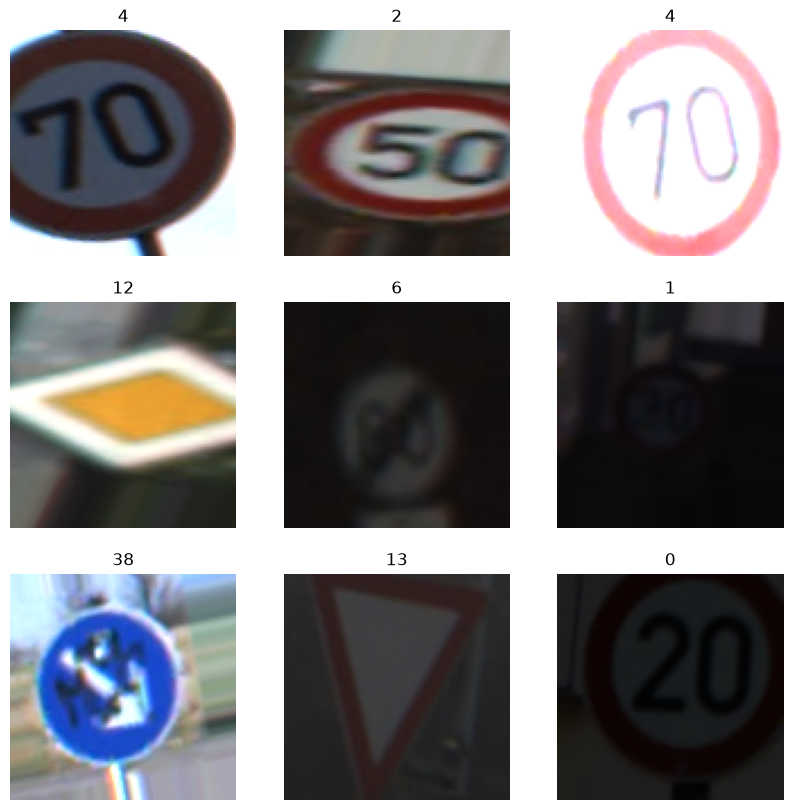

In [60]:
# View 9 images and their class labels
plt.figure(figsize=(10, 10))
images, labels = next(train_generator)  # Assuming train_generator is a generator
batch_size = images.shape[0]

for i in range(min(9, batch_size)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((images[i] * 255).astype("uint8"))
    plt.title(int(labels[i]))
    plt.axis("off")

plt.show()

In [61]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, Input

# 1. Load the pre-trained MobileNetV2 backbone
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(100, 100, 3)
)

# 2. Freeze the backbone completely
base_model.trainable = False

# 3. Construct the network using the Functional API
inputs = Input(shape=(100, 100, 3))

# Step A: Preprocessing Layer (scales [0, 1] to [-1, 1])
x = layers.Rescaling(scale=2.0, offset=-1.0)(inputs)

# Step B: Inject the base model and FORCEMENT of inference mode for Batchnorm
x = base_model(x, training=False)

# Step C: Regularization and classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(43)(x)  # Raw logits for your 43 classes

# Bind inputs and outputs into the final model object
model = models.Model(inputs, outputs, name="Functional_MobileNetV2")

# View your corrected architecture layout
model.summary()

C:\Users\elijk\AppData\Local\Temp\ipykernel_42036\195690081.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "Functional_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,499 (9.26 MB)

 Trainable params: 169,515 (662.17 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [62]:
# === LOCAL MODEL SAVE DIRECTORY ===
# Models will be saved locally instead of Google Drive.
model_save_dir = os.path.join(DATA_DIR, 'saved_models')
os.makedirs(model_save_dir, exist_ok=True)
print(f"Models will be saved to: {model_save_dir}")

Models will be saved to: c:\Users\elijk\Documents\DS-450\signs\roadsigns_data\saved_models


In [63]:
# 1. Create a custom wrapper to handle sparse integer labels on the fly
class SparseF1Score(tf.keras.metrics.F1Score):
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Flatten the sparse target and convert to one-hot encoding (43 classes)
        y_true_one_hot = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32), depth=43)
        return super().update_state(y_true_one_hot, y_pred, sample_weight)

# Use our new custom sparse wrapper
f1_metric = SparseF1Score(average="macro", name="f1_score")

# 2. Compile using SPARSE loss exactly like you had it
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy', f1_metric]
)

# 3. Early Stopping and Checkpoint monitors stay the same
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_f1_score',
    patience=3,
    restore_best_weights=True
)

checkpoint_path = os.path.join(model_save_dir, 'best_road_signs_f1_model.keras')

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_f1_score',
    save_best_only=True,
    mode='max',
    verbose=1
)

print(f"Checkpoint will be saved to: {checkpoint_path}")

# 4. Fit the model safely
history = model.fit(
    train_generator,
    epochs=0,
    validation_data=validation_generator,
    callbacks=[checkpoint_callback, early_stopping]
)

Checkpoint will be saved to: c:\Users\elijk\Documents\DS-450\signs\roadsigns_data\saved_models\best_road_signs_f1_model.keras


In [64]:
# plt.plot(history.history['accuracy'], label='accuracy')
# plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.ylim([0.5, 1])
# plt.legend(loc='lower right')

# # Unpack all 3 values returned by the model
# test_loss, test_acc, test_f1 = model.evaluate(validation_generator, verbose=2)

# print(f"Validation Loss:     {test_loss:.4f}")
# print(f"Validation Accuracy: {test_acc * 100:.2f}%")
# print(f"Validation F1-Score: {test_f1:.4f}")

In [65]:
from tensorflow.keras.models import load_model
import tensorflow as tf

# 1. Load your absolute best weights from the local checkpoint
print("Loading the peak model checkpoint...")
model = load_model(
    checkpoint_path,
    custom_objects={'SparseF1Score': SparseF1Score}
)

# 2. Extract the base MobileNetV2 layer block
base_model_layer = model.get_layer('mobilenetv2_1.00_224')

# 3. SURGICAL UNFREEZE: Loop through and keep BatchNormalization locked down!
base_model_layer.trainable = True
for layer in base_model_layer.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization) or 'BatchNormalization' in layer.__class__.__name__:
        layer.trainable = False

# 4. Recompile with your microscopic fine-tuning learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy', f1_metric]
)

# 5. Set up the clean fine-tuning Early Stopping monitor
early_stopping_ft = tf.keras.callbacks.EarlyStopping(
    monitor='val_f1_score',
    patience=5,
    restore_best_weights=True
)

# 6. Fine-tune smoothly
history_fine_tune = model.fit(
    train_generator,
    epochs=40,
    validation_data=validation_generator,
    callbacks=[checkpoint_callback, early_stopping_ft]
)

Loading the peak model checkpoint...
Epoch 1/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9767 - f1_score: 0.9726 - loss: 0.0750
Epoch 1: val_f1_score improved from None to 0.95340, saving model to c:\Users\elijk\Documents\DS-450\signs\roadsigns_data\saved_models\best_road_signs_f1_model.keras

Epoch 1: finished saving model to c:\Users\elijk\Documents\DS-450\signs\roadsigns_data\saved_models\best_road_signs_f1_model.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.9755 - f1_score: 0.9723 - loss: 0.0793 - val_accuracy: 0.9702 - val_f1_score: 0.9534 - val_loss: 0.1084
Epoch 2/40
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 962ms/step - accuracy: 0.9772 - f1_score: 0.9722 - loss: 0.0701
Epoch 2: val_f1_score improved from 0.95340 to 0.95538, saving model to c:\Users\elijk\Documents\DS-450\signs\roadsigns_data\saved_models\best_road_signs_f1_model.keras

Epoch 2: finished saving model to c:\Users\elijk\Documents\DS-450\signs\roadsigns_data\saved_models\best_road_signs_f1_model

31/31 - 10s - 322ms/step - accuracy: 0.9750 - f1_score: 0.9572 - loss: 0.0939
Validation Loss:     0.0939
Validation Accuracy: 97.50%
Validation F1-Score: 0.9572


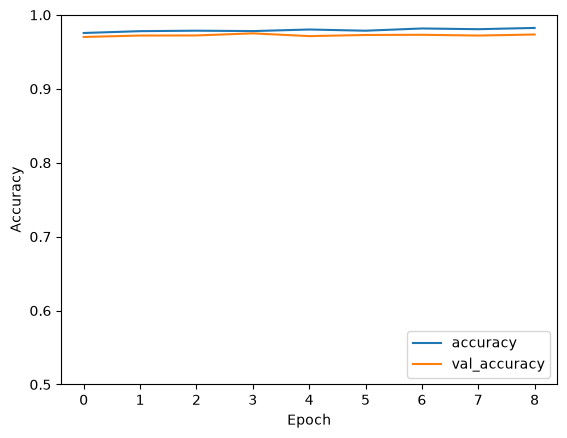

In [66]:
plt.plot(history_fine_tune.history['accuracy'], label='accuracy')
plt.plot(history_fine_tune.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

# Unpack all 3 values returned by the model
test_loss, test_acc, test_f1 = model.evaluate(validation_generator, verbose=2)

print(f"Validation Loss:     {test_loss:.4f}")
print(f"Validation Accuracy: {test_acc * 100:.2f}%")
print(f"Validation F1-Score: {test_f1:.4f}")

In [67]:
predictions = model.predict(validation_generator)


31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 340ms/step


Found 7841 images belonging to 43 classes.
Generating predictions for the validation dataset...
246/246 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step

Overall Validation Accuracy: 97.50%

Detailed Validation Classification Report:
                                   precision    recall  f1-score   support

                         Speed_20       1.00      0.88      0.94        42
                         Speed_30       0.94      0.96      0.95       444
                         Speed_50       0.94      0.96      0.95       450
                         Speed_60       1.00      0.97      0.98       282
                         Speed_70       0.98      0.92      0.95       396
                         Speed_80       0.98      0.99      0.99       372
                 Speed_Limit_Ends       1.00      1.00      1.00        84
                        Speed_100       0.99      1.00      0.99       288
                        Speed_120       0.97      1.00      0.98       282
            Overtaking_Prohib

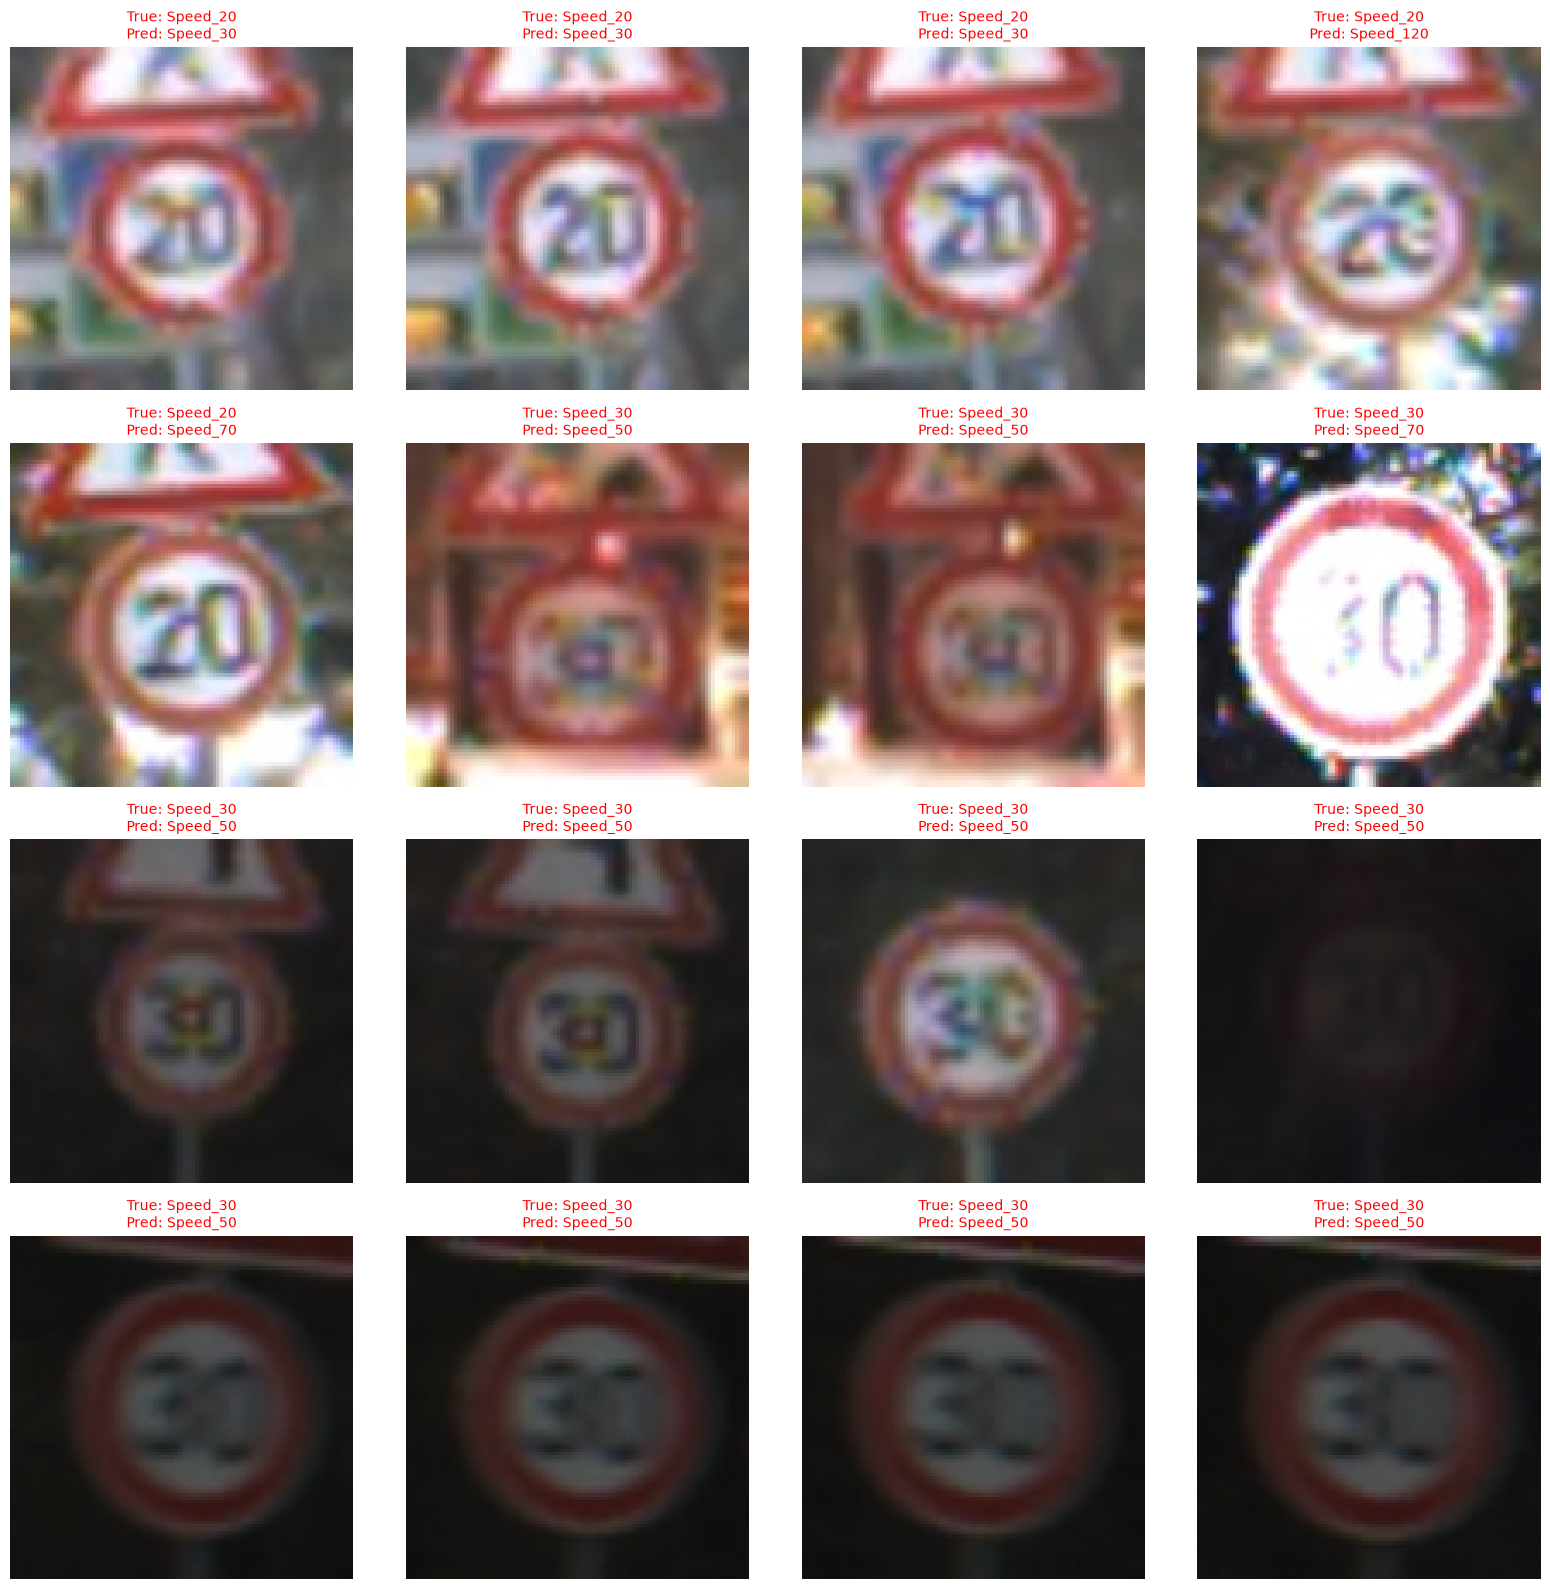

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.preprocessing.image import load_img

# 1. Create a fresh, dedicated evaluation generator to completely avoid the shuffle trap
val_eval_generator = validation_datagen.flow_from_directory(
        training_dir,
        target_size=image_size,
        batch_size=32,
        class_mode='sparse',
        subset="validation",
        seed=42,
        shuffle=False # Unshuffled from the very start
)

print("Generating predictions for the validation dataset...")
val_probabilities = model.predict(val_eval_generator)
val_predictions = np.argmax(val_probabilities, axis=1)

# 2. Extract the true validation labels
y_true_val = val_eval_generator.classes

# 3. Calculate and print overall validation accuracy
val_accuracy = accuracy_score(y_true_val, val_predictions)
print("\n" + "="*50)
print(f"Overall Validation Accuracy: {val_accuracy * 100:.2f}%")
print("="*50)

# 4. Print the detailed classification report
print("\nDetailed Validation Classification Report:")
print(classification_report(y_true_val, val_predictions, labels=range(43), target_names=target_names))

# 5. Find all misclassified indices
wrong_indices_val = np.where(y_true_val != val_predictions)[0]
total_wrong = len(wrong_indices_val)
print(f"\nTotal misclassified validation images: {total_wrong} out of {len(y_true_val)}")

# 6. Plot a safe sample of the errors (First 16 images)
max_images_to_show = 16
images_to_show = wrong_indices_val[:max_images_to_show]

print(f"Displaying the first {len(images_to_show)} misclassified images:")
columns = 4
rows = (len(images_to_show) + columns - 1) // columns
plt.figure(figsize=(16, rows * 4))

for i, idx in enumerate(images_to_show):
    # Pull paths cleanly from our new evaluation generator
    img_path = val_eval_generator.filepaths[idx]
    img = load_img(img_path)

    true_label_name = target_names[y_true_val[idx]]
    pred_label_name = target_names[val_predictions[idx]]

    ax = plt.subplot(rows, columns, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label_name}\nPred: {pred_label_name}", color='red', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Testing the model
Once you have built and trained your model, the next step is to run the mini holdout images through it and see how well your model does at making predictions for images it has never seen before.

Since loading these images and formatting them for the model can be tricky, you may find the following code useful. This code only uses your model to predict the class label for a given image. You'll still need to compare those predictions to the "ground truth" class labels in `mini_holdout_answers.csv` to evaluate how well the model does.

Make sure to use the insights gained from the mini hold out dataset in your executive summary.

```python
from tensorflow.keras.preprocessing import image_dataset_from_directory

test_dir = DATA_DIR  # Points to your local roadsigns_data folder

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['mini_holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]
```

In [69]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

test_dir = DATA_DIR  # Points to your local roadsigns_data folder

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['mini_holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]

# Save to local CSV — single column, header "predictions", no index
predictions_df = pd.DataFrame({'predictions': predictions})
submission_path = os.path.join(model_save_dir, 'Sanhedrine-transferE-module5-predictions.csv')
predictions_df.to_csv(submission_path, index=False)
print(f"Submission saved to: {submission_path}")
print(f"Total predictions: {len(predictions)}")
print(f"Unique classes: {len(set(predictions))}")
print(f"Class range: {min(predictions)} to {max(predictions)}")

Found 201 images belonging to 1 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Submission saved to: c:\Users\elijk\Documents\DS-450\signs\roadsigns_data\saved_models\Sanhedrine-transferE-module5-predictions.csv
Total predictions: 201
Unique classes: 38
Class range: 1 to 41


In [70]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the correct answers from local path
answers_df = pd.read_csv(mini_holdout_answers)

# Take a quick look at the first few rows to confirm the column name
print("CSV Columns:", answers_df.columns.tolist())
print(answers_df.head(), "\n" + "="*50)

# 2. Extract the true class labels
y_true = answers_df['ClassId'].values

# 3. Calculate and print the overall accuracy
accuracy = accuracy_score(y_true, predictions)
print(f"Mini Holdout Accuracy: {accuracy * 100:.2f}%")

# 4. Show a detailed breakdown per road sign class
print("\nClassification Report:")
# Add labels=range(43) to force it to map all 43 target names correctly
print(classification_report(y_true, predictions, labels=range(43), target_names=target_names))

CSV Columns: ['Filename', 'ClassId']
    Filename  ClassId
0  00000.jpg       16
1  00001.jpg        1
2  00002.jpg       38
3  00003.jpg       33
4  00004.jpg       11 
Mini Holdout Accuracy: 97.01%

Classification Report:
                                   precision    recall  f1-score   support

                         Speed_20       0.00      0.00      0.00         0
                         Speed_30       1.00      0.91      0.95        11
                         Speed_50       1.00      1.00      1.00         8
                         Speed_60       0.91      1.00      0.95        10
                         Speed_70       1.00      1.00      1.00         9
                         Speed_80       0.83      1.00      0.91         5
                 Speed_Limit_Ends       1.00      1.00      1.00         3
                        Speed_100       1.00      1.00      1.00         8
                        Speed_120       1.00      0.83      0.91         6
            Overtaking_Pr

c:\Users\elijk\Documents\DS-450\signs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elijk\Documents\DS-450\signs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elijk\Documents\DS-450\signs\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

Total misclassified images: 6 out of 201


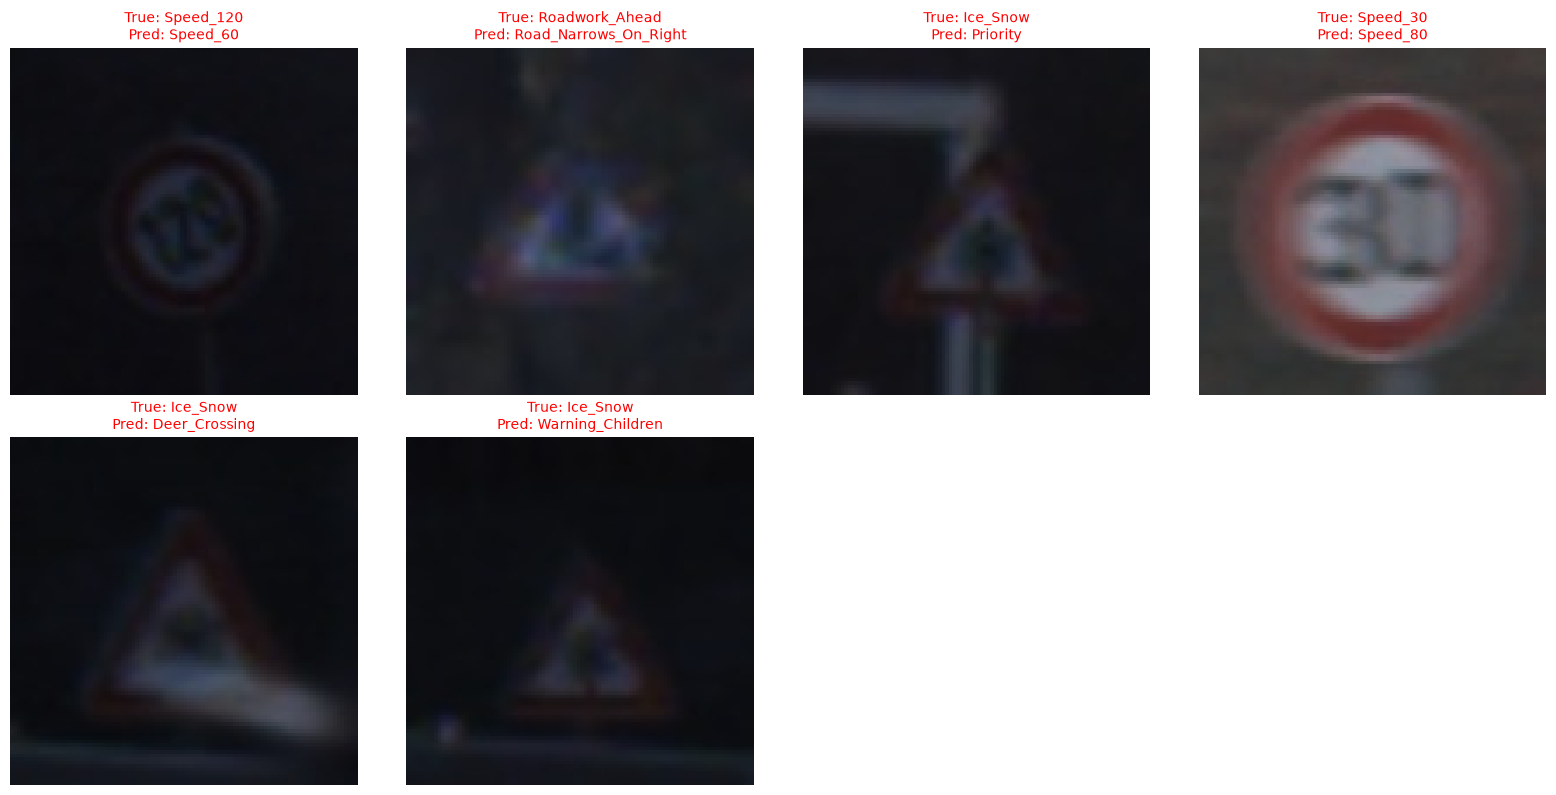

In [71]:
from tensorflow.keras.preprocessing.image import load_img

# 1. Find the index of every image where the prediction didn't match the true answer
wrong_indices = np.where(y_true != np.array(predictions))[0]
print(f"Total misclassified images: {len(wrong_indices)} out of {len(y_true)}")

# 2. Set up a dynamic grid to display them (4 images per row)
columns = 4
rows = (len(wrong_indices) + columns - 1) // columns
plt.figure(figsize=(16, rows * 4))

# 3. Loop through the wrong entries, load their images, and plot them
for i, idx in enumerate(wrong_indices):
    # Grab the exact file path from the generator's internal file list
    img_path = test_generator.filepaths[idx]
    img = load_img(img_path)

    # Get the text names for both labels
    true_label_name = target_names[y_true[idx]]
    pred_label_name = target_names[predictions[idx]]

    # Plotting
    ax = plt.subplot(rows, columns, i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label_name}\nPred: {pred_label_name}", color='red', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Full Holdout Predictions — Submission

Run this cell to generate your submission CSV. The file will be saved in the `saved_models` folder inside your `roadsigns_data` directory.

**CSV format requirements:**
- Single column with header `predictions` (no quotes)
- One prediction per row (integer class IDs)
- No index column
- Filename format: `team8-module2-predictions.csv` *(replace with your team #)*

In [72]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

test_dir = DATA_DIR  # Points to your local roadsigns_data folder

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]

# Save to local CSV — single column, header "predictions", no index
predictions_df = pd.DataFrame({'predictions': predictions})
submission_path = os.path.join(model_save_dir, 'Sanhedrine-transferE-module5-predictions.csv')
predictions_df.to_csv(submission_path, index=False)
print(f"Submission saved to: {submission_path}")
print(f"Total predictions: {len(predictions)}")
print(f"Unique classes: {len(set(predictions))}")
print(f"Class range: {min(predictions)} to {max(predictions)}")

Found 12630 images belonging to 1 classes.
395/395 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step
Submission saved to: c:\Users\elijk\Documents\DS-450\signs\roadsigns_data\saved_models\Sanhedrine-transferE-module5-predictions.csv
Total predictions: 12630
Unique classes: 43
Class range: 0 to 42
